<a href="https://colab.research.google.com/github/vadhri/cfd-notebook/blob/main/1d_unsteady_heat_conduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Finite Volume Method for Transient (Unsteady) Flows

General transport equation for scalar $\phi$

$$
\frac{\partial (\rho \phi)}{\partial t}
+ \nabla \cdot (\rho \mathbf{u} \phi)
= \nabla \cdot (\Gamma \nabla \phi) + S_\phi
$$

Transient + Convective = Diffusive + Source

For 1D heat conduction, let $\phi = T$, the temperature.

$$
\rho c \frac{\partial T}{\partial t}
= \frac{\partial}{\partial x} \left( k \frac{\partial T}{\partial x} \right) + S
$$

Integrate over CV and time $(t \rightarrow t+\Delta t)$

$$
\int_{CV} \left( \int_{t}^{t+\Delta t}
\rho c \frac{\partial T}{\partial t} \, dt \right) dV
=
\int_{t}^{t+\Delta t} \left( \int_{CV}
\frac{\partial}{\partial x} \left( k \frac{\partial T}{\partial x} \right)
dV \right) dt
$$

$$
+ \int_{t}^{t+\Delta t} \left( \int_{CV} S \, dV \right) dt
$$

(1) Transient term

$$
\int_{CV} \left( \int_{t}^{t+\Delta t}
\rho c \frac{\partial T}{\partial t} \, dt \right) dV
$$

$$
= \rho c \left( T_P^n - T_P^0 \right) \Delta V
$$

(2) Diffusion term

$$
\int_{t}^{t+\Delta t}
\left[
\int_{CV}
\frac{\partial}{\partial x}
\left( k \frac{\partial T}{\partial x} \right)
\cdot A \, dx
\right] dt
$$

$$
= \int_{t}^{t+\Delta t}
\left[
\left( k A \frac{dT}{dx} \right)_e
-
\left( k A \frac{dT}{dx} \right)_w
\right] dt
$$

$$
= \int_{t}^{t+\Delta t}
\left[
k A \left( \frac{T_E - T_P}{\delta x_{PE}} \right)
-
k A \left( \frac{T_P - T_W}{\delta x_{WP}} \right)
\right] dt
$$

Source term

$$
\int_{t}^{t+\Delta t}
\left( \int_{CV} S \, dV \right) dt
$$

Combine all terms

$$
\rho c \left( T_P^n - T_P^0 \right) \Delta V
=
\int_{t}^{t+\Delta t}
\left[
k A \left( \frac{T_E - T_P}{\delta x_{PE}} \right)
-
k A \left( \frac{T_P - T_W}{\delta x_{WP}} \right)
\right] dt
+
\int_{t}^{t+\Delta t}
\left( S \, \Delta V \right) dt
$$

To integrate over t, t+$\Delta$t, we can take the temperatures at t or t+$\Delta$t or a combination of both.

$$
I = \int_{t}^{t+\Delta t} T_p \, dt
= \left[ \theta T_P^n + (1-\theta) T_P^0 \right] \Delta t
$$

Apply to full equation

$$
\rho c \left( T_P^n - T_P^0 \right) \Delta V
=
\Delta t \left[
\theta \left(
k A \frac{T_E^n - T_P^n}{\delta x_{PE}}
-
k A \frac{T_P^n - T_W^n}{\delta x_{WP}}
+ S^n \Delta V
\right)
\right.
$$

$$
\left.
+ (1-\theta) \left(
k A \frac{T_E^0 - T_P^0}{\delta x_{PE}}
-
k A \frac{T_P^0 - T_W^0}{\delta x_{WP}}
+ S^0 \Delta V
\right)
\right]
$$

Divide by $A \Delta t $ on both sides

$$
\rho c \left( \frac{T_P^n - T_P^0}{\Delta t} \right) \Delta x
=
\theta \left[
k \left( \frac{T_E^n - T_P^n}{\delta x_{PE}} \right)
-
k \left( \frac{T_P^n - T_W^n}{\delta x_{WP}} \right)
+ S^n \, \Delta x
\right]
+
(1-\theta) \left[
k \left( \frac{T_E^0 - T_P^0}{\delta x_{PE}} \right)
-
k \left( \frac{T_P^0 - T_W^0}{\delta x_{WP}} \right)
+ S^0 \, \Delta x
\right]
$$

Grouping all the coefficients together.

$$
\left[
\rho c \frac{\Delta x}{\Delta t}
+ \theta \left(
\frac{k}{\delta x_{PE}} + \frac{k}{\delta x_{WP}}
\right)
\right] T_P^n
$$

$$
=
\frac{k}{\delta x_{PE}} \left[ \theta T_E^n + (1-\theta) T_E^0 \right]
+
\frac{k}{\delta x_{WP}} \left[ \theta T_W^n + (1-\theta) T_W^0 \right]
$$

$$
+
\left[
\rho c \frac{\Delta x}{\Delta t}
- (1-\theta)\left(
\frac{k}{\delta x_{PE}} + \frac{k}{\delta x_{WP}}
\right)
\right] T_P^0
+ \bar{S} \Delta x
$$

Standard FVM coefficient form

$$
a_P T_P^n = a_E T_E^n + a_W T_W^n + b
$$

Coefficients

$$
a_E = \theta \frac{k}{\delta x_{PE}}, \quad
a_W = \theta \frac{k}{\delta x_{WP}}
$$

$$
a_P = \rho c \frac{\Delta x}{\Delta t}
+ a_E + a_W
$$

Source term

$$
b =
\rho c \frac{\Delta x}{\Delta t} T_P^0
+
(1-\theta) \left[
\frac{k}{\delta x_{PE}} T_E^0
+
\frac{k}{\delta x_{WP}} T_W^0
-
\left(
\frac{k}{\delta x_{PE}} + \frac{k}{\delta x_{WP}}
\right) T_P^0
\right]
+ \bar{S} \Delta x
$$

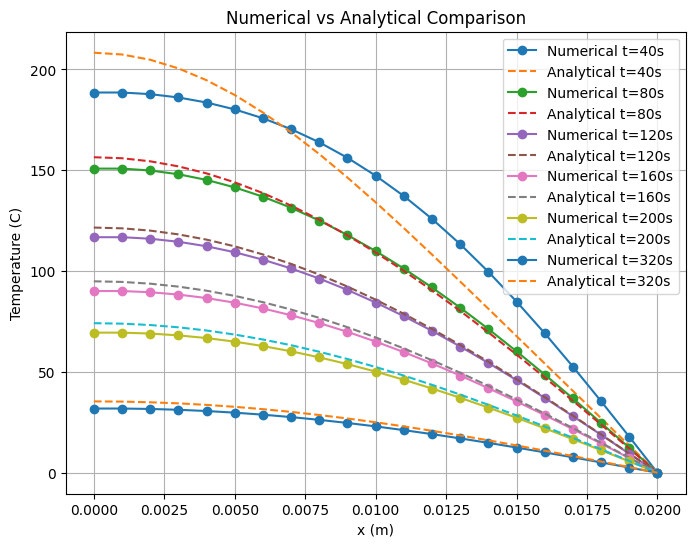


L2 Errors:
t = 40s → L2 error = 61.070406
t = 80s → L2 error = 11.480884
t = 120s → L2 error = 10.732758
t = 160s → L2 error = 12.119468
t = 200s → L2 error = 12.487610
t = 320s → L2 error = 10.207953


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# Parameters
# ------------------------
L = 0.02                # length (m)
k = 10                  # thermal conductivity
rho_c = 1e7             # rho * c
T_init = 200.0          # initial temp
T_east = 0.0            # boundary condition

Nx = 21                 # number of nodes
dx = L / (Nx - 1)

# Stability condition (explicit)
dt = rho_c * dx**2 / (2 * k)
dt *= 0.9  # safety factor

Fo = k * dt / (rho_c * dx**2)

# Time points
times = [40, 80, 120, 160, 200, 320]

# ------------------------
# Initialization
# ------------------------
T = np.ones(Nx) * T_init
T_new = T.copy()

results = {}

current_time = 0.0
t_end = max(times)

# ------------------------
# Time stepping (Explicit FVM)
# ------------------------
while current_time < t_end:

    # Interior nodes
    for i in range(1, Nx-1):
        T_new[i] = T[i] + Fo * (T[i+1] - 2*T[i] + T[i-1])

    # West boundary (insulated: dT/dx = 0)
    T_new[0] = T_new[1]

    # East boundary (Dirichlet)
    T_new[-1] = T_east

    # Update
    T[:] = T_new[:]
    current_time += dt

    # Store results
    for t_target in times:
        if abs(current_time - t_target) < dt:
            results[t_target] = T.copy()

# ------------------------
# Analytical solution
# ------------------------
def analytical_solution(x, t, L, alpha, T0, terms=300):
    T = np.zeros_like(x)

    for n in range(terms):
        m = 2*n + 1   # odd numbers: 1,3,5,...
        lam = m * np.pi / (2*L)

        T += (1/m) * np.exp(-alpha * lam**2 * t) * np.cos(lam * x)

    return (4*T0/np.pi) * T

alpha = k / rho_c

# ------------------------
# Plot comparison
# ------------------------
x = np.linspace(0, L, Nx)

plt.figure(figsize=(8,6))

for t in times:
    T_num = results[t]
    T_ana = analytical_solution(x, t, L, alpha, T_init)

    plt.plot(x, T_num, 'o-', label=f'Numerical t={t}s')
    plt.plot(x, T_ana, '--', label=f'Analytical t={t}s')

plt.xlabel("x (m)")
plt.ylabel("Temperature (C)")
plt.title("Numerical vs Analytical Comparison")
plt.legend()
plt.grid()
plt.show()

# ------------------------
# Error calculation
# ------------------------
print("\nL2 Errors:")
for t in times:
    T_num = results[t]
    T_ana = analytical_solution(x, t, L, alpha, T_init)

    error = np.linalg.norm(T_num - T_ana, ord=2)
    print(f"t = {t}s → L2 error = {error:.6f}")